---
execute:
  enabled: false
number-sections: false
---

# Practicum: From Pixels to CNN Features {#ch-practice-cnn .unnumbered}

**Theory connection:** [Convolutional Neural Networks: Learning Spatial Structure](../../chapters/09a-convolutional-neural-networks.qmd#ch-cnn)

This practicum tells one continuous story. You will first solve MNIST with a
multilayer perceptron (MLP), stop to make convolution visible, solve the same
task with a convolutional neural network (CNN), and finally inspect how kernels
activate on handwritten 1s and 7s.

Download the [complete Jupyter notebook](notebooks/cnn-mnist-practicum.ipynb).
It contains the runnable code and representative executed output. The web and
print book retain a concise set of results so that the explanation remains
readable without requiring TensorFlow during rendering.

To reproduce the authoring environment from the repository root:

```bash
python3.12 -m venv .venv
source .venv/bin/activate
python -m pip install -r practice/requirements-cnn.txt
jupyter lab practice/notebooks/cnn-mnist-practicum.ipynb
```

The `.venv` directory is intentionally ignored by Git. A standard Google Colab
runtime is an easier alternative when local TensorFlow installation is inconvenient.

## Learning Question and Evidence Rules {#sec-pr-cnn-question}

> What changes when a classifier preserves spatial neighborhoods and reuses
> local detectors before making a class prediction?

The comparison controls the data split, scaling, optimizer, batch size,
early-stopping rule, and approximate parameter budget. The architecture is the
main planned difference. The validation set guides stopping; the test set is
evaluated only after each model is fixed.

By the end, you should be able to:

- explain what flattening preserves and what it no longer makes explicit;
- calculate and visualize a kernel response;
- distinguish a kernel, a feature map, and a class prediction;
- read training and validation loss as evidence about fit; and
- make a cautious, evidence-based MLP-versus-CNN comparison.

::: {.callout-note title="Representative results, not universal constants"}
The displayed results come from one seeded full-data run using TensorFlow 2.20
and Keras 3.15. Small numerical differences are normal across software and
hardware. Your explanations should survive those differences.
:::

## Setup: One Dataset, Three Roles {#sec-pr-cnn-setup}

MNIST contains $60{,}000$ training images and $10{,}000$ test images. We shuffle
the original training data once, use $54{,}000$ examples for fitting, and reserve
$6{,}000$ for validation. Each image is a $28\times28$ grayscale array.

![One example from each MNIST class. The task is simple enough to train quickly, but the handwriting contains varying strokes, slants, and loops.](../../assets/figures/chapter09a/practicum/mnist-examples.png){#fig-pr-cnn-mnist-examples fig-alt="Ten grayscale MNIST images arranged in two rows, one for each digit from zero through nine." width="82%"}

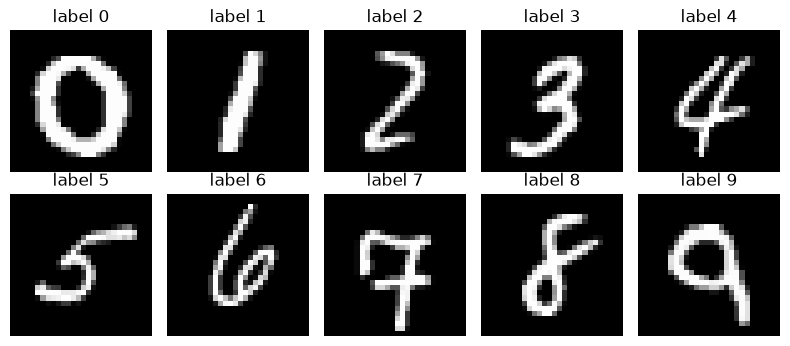

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from keras import layers

SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 12
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

(x_train_raw, y_train_raw), (x_test_raw, y_test) = (
    keras.datasets.mnist.load_data()
)

# Reproduce the same 54,000/6,000 fit/validation split.
order = np.random.default_rng(SEED).permutation(len(x_train_raw))
x_train_raw, y_train_raw = x_train_raw[order], y_train_raw[order]
x_fit_raw, x_val_raw = x_train_raw[:54000], x_train_raw[54000:]
y_fit, y_val = y_train_raw[:54000], y_train_raw[54000:]

def scale(images):
    return images.astype("float32") / 255.0

fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for digit, axis in enumerate(axes.flat):
    index = np.flatnonzero(y_fit == digit)[0]
    axis.imshow(x_fit_raw[index], cmap="gray")
    axis.set_title(f"label {digit}")
    axis.axis("off")
plt.tight_layout()

**Check before continuing.** Which set may influence the stopping epoch? Why
should neither the validation set nor test set be passed to `model.fit` as
training examples?

## Part I: Establish an MLP Baseline {#sec-pr-cnn-mlp}

### Flatten the Grid {#sec-pr-cnn-flatten}

The MLP receives a vector, not an image grid:

In [2]:
x_fit_mlp = scale(x_fit_raw).reshape(-1, 784)
x_val_mlp = scale(x_val_raw).reshape(-1, 784)
x_test_mlp = scale(x_test_raw).reshape(-1, 784)

assert x_fit_mlp.shape == (54000, 784)
assert x_val_mlp.shape == (6000, 784)
assert x_test_mlp.shape == (10000, 784)

![A digit 7 represented as a two-dimensional image and as the same 784 values in row-major vector order.](../../assets/figures/chapter09a/practicum/flatten-grid-versus-vector.png){#fig-pr-cnn-flatten fig-alt="A digit seven appears on a 28 by 28 grid at left. At right, a line plot shows the same 784 pixel values after flattening." width="95%"}

Flattening neither deletes nor randomizes a pixel. It changes how the model is
allowed to use the values: two neighboring pixels no longer share an explicit
two-dimensional neighborhood, and the same stroke in a new location reaches
different dense-layer weights.

**Explain.** If pixel $(10,10)$ and pixel $(10,11)$ are adjacent in the grid,
where do they appear in the vector? Why can the MLP still learn from them, even
though it does not reuse one local detector across locations?

### Build and Train the MLP {#sec-pr-cnn-mlp-model}

The model is intentionally ordinary and compact:

In [3]:
def build_mlp():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="mnist_mlp")
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

mlp_model = build_mlp()
assert mlp_model.count_params() == 109386
mlp_model.summary()

Model: "mnist_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Use validation loss, not training accuracy, to decide when to stop:

In [4]:
def fit_model(model, x_fit, x_val):
    stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )
    start = time.perf_counter()
    history = model.fit(
        x_fit,
        y_fit,
        validation_data=(x_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=MAX_EPOCHS,
        callbacks=[stop],
        verbose=2,
    )
    return history.history, time.perf_counter() - start

mlp_history, mlp_seconds = fit_model(
    mlp_model, x_fit_mlp, x_val_mlp
)
mlp_loss, mlp_accuracy = mlp_model.evaluate(
    x_test_mlp, y_test, verbose=0
)
mlp_pred = mlp_model.predict(x_test_mlp, verbose=0).argmax(axis=1)

Epoch 1/12


2026-08-25 10:49:08.453476: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


422/422 - 1s - 2ms/step - accuracy: 0.9013 - loss: 0.3487 - val_accuracy: 0.9505 - val_loss: 0.1793


Epoch 2/12


422/422 - 1s - 1ms/step - accuracy: 0.9555 - loss: 0.1498 - val_accuracy: 0.9593 - val_loss: 0.1325


...

Epoch 9/12


422/422 - 1s - 1ms/step - accuracy: 0.9929 - loss: 0.0271 - val_accuracy: 0.9722 - val_loss: 0.0981


Epoch 10/12


422/422 - 1s - 1ms/step - accuracy: 0.9941 - loss: 0.0219 - val_accuracy: 0.9710 - val_loss: 0.1122


2026-08-25 10:49:14.173324: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Record the parameter count, stopping epoch, lowest validation loss, test loss,
test accuracy, number of errors, and training time. Do not tune the MLP after
looking at the CNN's test results; that would make the comparison asymmetric.

## Part II: Make Convolution Visible {#sec-pr-cnn-concepts}

### One Transparent Operation {#sec-pr-cnn-cross-correlation}

A kernel produces one number per local window: multiply matching entries, add
the products, and then move the same weights to the next location. The function
below implements valid two-dimensional cross-correlation for one channel:

In [5]:
def cross_correlate2d(image, kernel, stride=1, padding=0):
    image = np.pad(np.asarray(image, dtype=float), padding)
    kernel = np.asarray(kernel, dtype=float)
    kh, kw = kernel.shape
    out_h = (image.shape[0] - kh) // stride + 1
    out_w = (image.shape[1] - kw) // stride + 1
    output = np.empty((out_h, out_w))

    for row in range(out_h):
        for col in range(out_w):
            r, c = row * stride, col * stride
            window = image[r:r + kh, c:c + kw]
            output[row, col] = np.sum(window * kernel)
    return output

Test the worked example from the theory chapter:

In [6]:
small_image = np.array([
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [1, 1, 0, 0],
    [1, 1, 0, 0],
], dtype=float)

boundary_kernel = np.array([[1, -1], [1, -1]], dtype=float)
feature_map = cross_correlate2d(small_image, boundary_kernel)

expected = np.array([[0, 2, 0], [0, 2, 0], [0, 2, 0]])
np.testing.assert_array_equal(feature_map, expected)
feature_map

array([[0., 2., 0.],
       [0., 2., 0.],
       [0., 2., 0.]])

**Predict before running.** What changes when `stride=2`? What padding keeps a
$28\times28$ image at the same spatial size with a $3\times3$ kernel and stride
one? Verify both answers with array shapes.

### Kernels Produce Evidence, Not Labels {#sec-pr-cnn-hand-kernels}

The next comparison uses three hand-designed $3\times3$ kernels. After
cross-correlation, ReLU sets negative responses to zero. Bright locations show
where a local window agrees with a kernel.

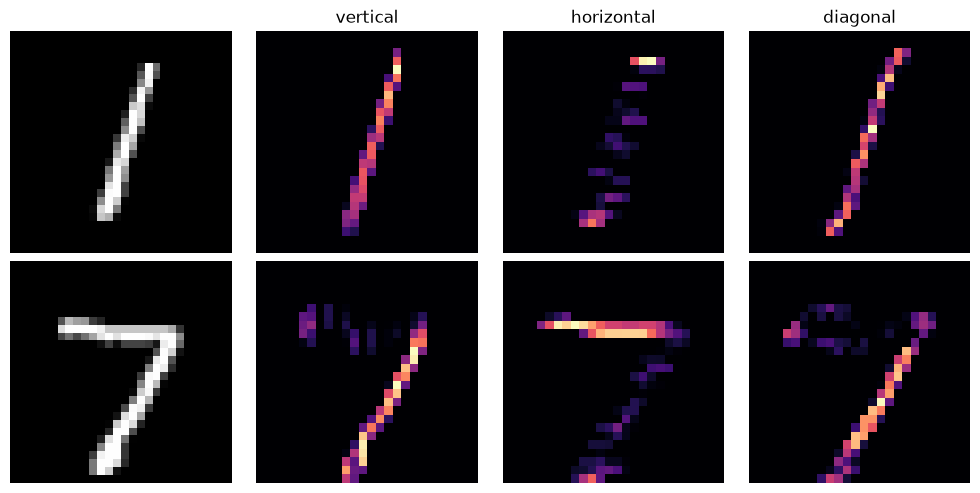

In [7]:
kernels = {
    "vertical": np.array([
        [-1, 2, -1], [-1, 2, -1], [-1, 2, -1]
    ]),
    "horizontal": np.array([
        [-1, -1, -1], [2, 2, 2], [-1, -1, -1]
    ]),
    "diagonal": np.array([
        [-1, -1, 2], [-1, 2, -1], [2, -1, -1]
    ]),
}

def relu(response):
    return np.maximum(response, 0)

indices = [np.flatnonzero(y_test == digit)[0] for digit in (1, 7)]
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for row, (digit, index) in enumerate(zip((1, 7), indices)):
    image = scale(x_test_raw[index])
    axes[row, 0].imshow(image, cmap="gray")
    axes[row, 0].set_ylabel(f"digit {digit}")
    axes[row, 0].axis("off")
    for col, (name, kernel) in enumerate(kernels.items(), start=1):
        response = relu(cross_correlate2d(image, kernel))
        axes[row, col].imshow(response, cmap="magma")
        axes[row, col].set_title(name if row == 0 else "")
        axes[row, col].axis("off")
plt.tight_layout()

![A digit 1 and a digit 7 passed through vertical, horizontal, and diagonal hand-designed kernels. Bright regions mark strong positive responses.](../../assets/figures/chapter09a/practicum/hand-kernel-activations-1-7.png){#fig-pr-cnn-hand-kernels fig-alt="Two rows compare digits one and seven. Three heatmaps in each row show activation from vertical, horizontal, and diagonal stroke kernels." width="100%"}

The vertical and diagonal kernels respond to parts of *both* digits. The
horizontal kernel responds strongly to the top bar of this 7, but it also finds
short horizontal transitions in the 1. A single feature map is therefore not a
class decision. A CNN learns several filters and combines their spatial patterns
across layers.

**Experiment.** Change one kernel entry at a time. For each change, predict
which region will brighten or darken, then test your prediction. Finally design
a kernel for a falling diagonal. State why none of these kernels alone is a
reliable digit classifier.

### Pooling and Parameter Counting {#sec-pr-cnn-pooling}

Max pooling retains the largest activation in each window and learns no weights:

In [8]:
def max_pool2d(feature_map, size=2, stride=2):
    out_h = (feature_map.shape[0] - size) // stride + 1
    out_w = (feature_map.shape[1] - size) // stride + 1
    output = np.empty((out_h, out_w))
    for row in range(out_h):
        for col in range(out_w):
            r, c = row * stride, col * stride
            output[row, col] = feature_map[
                r:r + size, c:c + size
            ].max()
    return output

def conv_parameters(kh, kw, channels_in, channels_out):
    weights = kh * kw * channels_in * channels_out
    biases = channels_out
    return weights + biases

assert conv_parameters(3, 3, 1, 16) == 160
assert conv_parameters(3, 3, 16, 32) == 4640

Why does image height not appear in the parameter formula? Why does it still
affect the number of operations and the size of the feature map?

## Part III: Replace the MLP with a CNN {#sec-pr-cnn-model}

### Preserve the Grid and Add a Channel Axis {#sec-pr-cnn-cnn-data}

The CNN sees the same scaled values but retains their two-dimensional arrangement:

In [9]:
x_fit_cnn = scale(x_fit_raw)[..., np.newaxis]
x_val_cnn = scale(x_val_raw)[..., np.newaxis]
x_test_cnn = scale(x_test_raw)[..., np.newaxis]

assert x_fit_cnn.shape == (54000, 28, 28, 1)
assert x_val_cnn.shape == (6000, 28, 28, 1)
assert x_test_cnn.shape == (10000, 28, 28, 1)

### Build a Nearly Parameter-Matched CNN {#sec-pr-cnn-cnn-model}

In [10]:
def build_cnn():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(
            16, 3, padding="same", activation="relu", name="conv_1"
        ),
        layers.MaxPooling2D(2),
        layers.Conv2D(
            32, 3, padding="same", activation="relu", name="conv_2"
        ),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="mnist_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

cnn_model = build_cnn()
assert cnn_model.count_params() == 105866
cnn_model.summary()

Model: "mnist_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

Before viewing the summary, calculate every output shape and parameter count.
Where are most CNN parameters located? What useful transformation occurs before
that large dense layer?

Train and evaluate under the same protocol:

In [11]:
cnn_history, cnn_seconds = fit_model(
    cnn_model, x_fit_cnn, x_val_cnn
)
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    x_test_cnn, y_test, verbose=0
)
cnn_pred = cnn_model.predict(x_test_cnn, verbose=0).argmax(axis=1)

results = {
    "MLP": {
        "accuracy": mlp_accuracy,
        "errors": int(np.sum(mlp_pred != y_test)),
        "parameters": mlp_model.count_params(),
    },
    "CNN": {
        "accuracy": cnn_accuracy,
        "errors": int(np.sum(cnn_pred != y_test)),
        "parameters": cnn_model.count_params(),
    },
}
results

Epoch 1/12


422/422 - 3s - 7ms/step - accuracy: 0.9203 - loss: 0.2828 - val_accuracy: 0.9743 - val_loss: 0.0874


Epoch 2/12


422/422 - 2s - 5ms/step - accuracy: 0.9773 - loss: 0.0752 - val_accuracy: 0.9803 - val_loss: 0.0612


Epoch 3/12


...

422/422 - 2s - 5ms/step - accuracy: 0.9913 - loss: 0.0287 - val_accuracy: 0.9863 - val_loss: 0.0464


Epoch 7/12


422/422 - 2s - 5ms/step - accuracy: 0.9930 - loss: 0.0235 - val_accuracy: 0.9862 - val_loss: 0.0494


2026-08-25 10:49:31.426870: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


{'MLP': {'accuracy': 0.975600004196167, 'errors': 244, 'parameters': 109386},
 'CNN': {'accuracy': 0.987500011920929, 'errors': 125, 'parameters': 105866}}

### Compare Outcomes, Then Explain {#sec-pr-cnn-results}

This representative run produced:

| Evidence | MLP | CNN |
|---|---:|---:|
| Trainable parameters | 109,386 | 105,866 |
| Epochs run | 10 | 7 |
| Lowest-validation-loss epoch | 8 | 5 |
| Test loss | 0.0874 | 0.0370 |
| Test accuracy | 97.56% | 98.75% |
| Misclassified test images | 244 | 125 |
| Training time on the authoring machine | 5.4 s | 17.1 s |

![Test accuracy, error count, and parameter count for the matched MLP and CNN run.](../../assets/figures/chapter09a/practicum/mlp-cnn-results.png){#fig-pr-cnn-results fig-alt="Three bar charts compare MLP and CNN test accuracy, misclassified test images, and trainable parameter counts." width="100%"}

The CNN reduced the test error count by $119$, a relative reduction of about
$49\%$, despite having slightly fewer parameters. This observation is consistent
with the value of locality and weight sharing for images. One run does not prove
that CNNs always win: the result depends on the data, protocol, implementation,
and task.

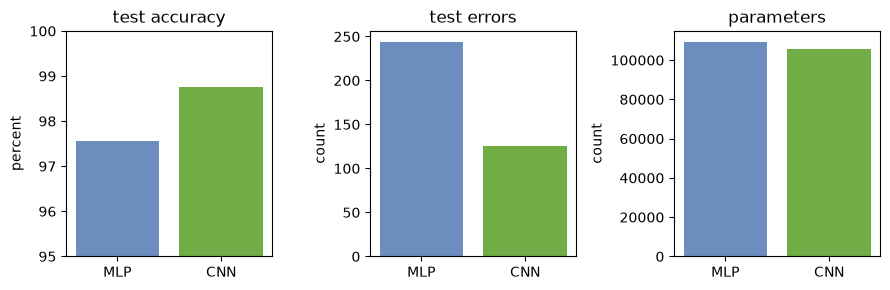

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
names = ["MLP", "CNN"]
colors = ["#6C8EBF", "#70AD47"]
axes[0].bar(names, [100 * results[n]["accuracy"] for n in names], color=colors)
axes[0].set(title="test accuracy", ylabel="percent", ylim=(95, 100))
axes[1].bar(names, [results[n]["errors"] for n in names], color=colors)
axes[1].set(title="test errors", ylabel="count")
axes[2].bar(names, [results[n]["parameters"] for n in names], color=colors)
axes[2].set(title="parameters", ylabel="count")
plt.tight_layout()

Inspecting individual errors keeps the aggregate comparison connected to the
images. The following code shows five mistakes from each model:

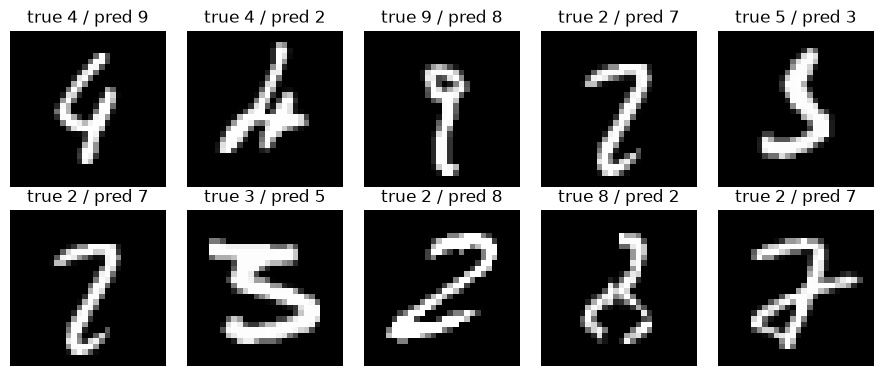

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(9, 3.8))
for row, (name, predictions) in enumerate(
    [("MLP", mlp_pred), ("CNN", cnn_pred)]
):
    wrong = np.flatnonzero(predictions != y_test)
    for axis, index in zip(axes[row], wrong[:5]):
        axis.imshow(x_test_raw[index], cmap="gray")
        axis.set_title(
            f"true {y_test[index]} / pred {predictions[index]}"
        )
        axis.axis("off")
    axes[row, 0].set_ylabel(name)
plt.tight_layout()

### Use Loss to Diagnose Overfitting {#sec-pr-cnn-learning-curves}

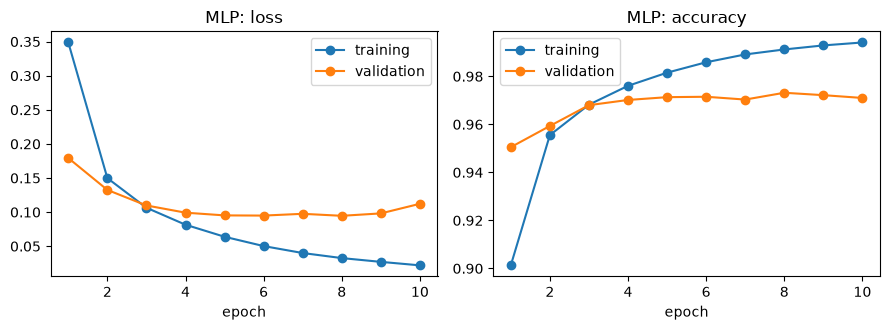

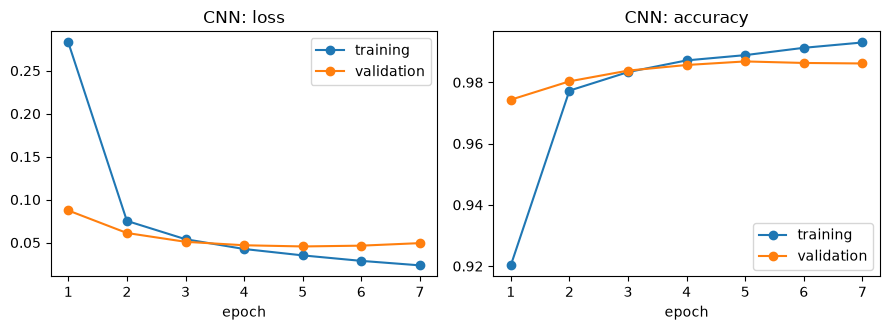

In [14]:
def plot_history(history, title):
    epochs = np.arange(1, len(history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
    axes[0].plot(epochs, history["loss"], marker="o", label="training")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="validation")
    axes[1].plot(epochs, history["accuracy"], marker="o", label="training")
    axes[1].plot(epochs, history["val_accuracy"], marker="o", label="validation")
    axes[0].set(title=f"{title}: loss", xlabel="epoch")
    axes[1].set(title=f"{title}: accuracy", xlabel="epoch")
    for axis in axes:
        axis.legend()
    plt.tight_layout()

plot_history(mlp_history, "MLP")
plot_history(cnn_history, "CNN")

![Training and validation loss and accuracy for the MLP and CNN. Dashed lines mark the minimum validation loss restored by early stopping.](../../assets/figures/chapter09a/practicum/mlp-cnn-learning-curves.png){#fig-pr-cnn-learning-curves fig-alt="Four line charts show MLP and CNN training and validation loss and accuracy across epochs." width="92%"}

For both models, training loss keeps falling after validation loss has stopped
improving. That widening gap is evidence of overfitting: the model continues to
fit the training examples without improving performance on held-out data.
Accuracy alone makes the turn harder to see; cross-entropy loss reacts to changes
in confidence even when the predicted class stays the same.

**Interpret.** Identify the first epoch after the minimum validation loss for
each model. Explain why early stopping restores the earlier weights rather than
keeping the final epoch. Then distinguish the evidence (the curve) from the
diagnosis (overfitting).

## Part IV: Return to Kernels: Learned Activations for 1 and 7 {#sec-pr-cnn-activations}

The hand-designed kernels made the mechanism transparent. We now ask what the
trained CNN learned. A small **probe model** returns the first convolutional
layer's output instead of the final softmax probabilities:

10 0


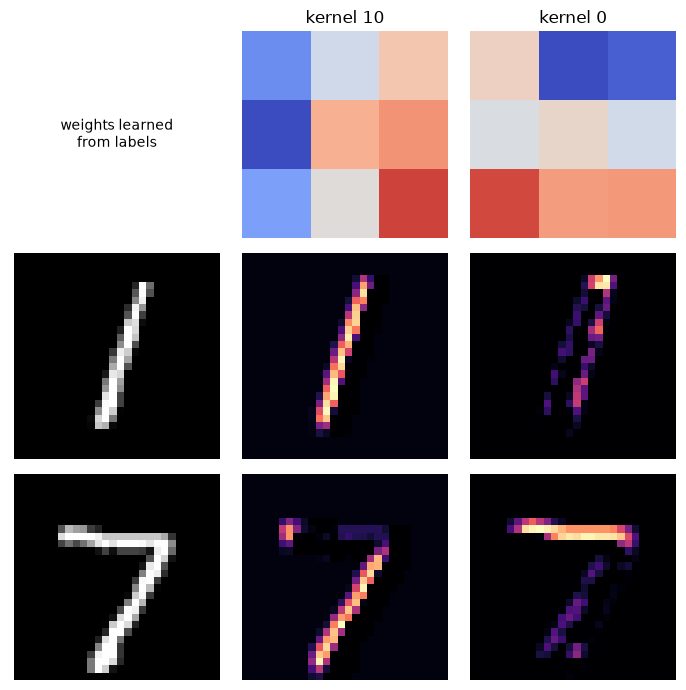

In [15]:
probe = keras.Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.get_layer("conv_1").output,
)
feature_maps = probe.predict(x_test_cnn, verbose=0)

# Compare each channel's share of total first-layer activation.
channel_means = feature_maps.mean(axis=(1, 2))
channel_share = channel_means / (
    channel_means.sum(axis=1, keepdims=True) + 1e-12
)
mean_for_1 = channel_share[y_test == 1].mean(axis=0)
mean_for_7 = channel_share[y_test == 7].mean(axis=0)
difference = mean_for_1 - mean_for_7

channel_1_relative = int(np.argmax(difference))
channel_7_relative = int(np.argmin(difference))
print(channel_1_relative, channel_7_relative)

first_kernels, _ = cnn_model.get_layer("conv_1").get_weights()
channels = [channel_1_relative, channel_7_relative]
indices = [np.flatnonzero(y_test == digit)[0] for digit in (1, 7)]

fig, axes = plt.subplots(3, 3, figsize=(7, 7))
axes[0, 0].text(
    0.5, 0.5, "weights learned\nfrom labels",
    ha="center", va="center"
)
axes[0, 0].axis("off")
for col, channel in enumerate(channels, start=1):
    kernel = first_kernels[:, :, 0, channel]
    limit = np.abs(kernel).max()
    axes[0, col].imshow(
        kernel, cmap="coolwarm", vmin=-limit, vmax=limit
    )
    axes[0, col].set_title(f"kernel {channel}")
    axes[0, col].axis("off")
for row, (digit, index) in enumerate(zip((1, 7), indices), start=1):
    axes[row, 0].imshow(x_test_raw[index], cmap="gray")
    axes[row, 0].set_ylabel(f"digit {digit}")
    axes[row, 0].axis("off")
    for col, channel in enumerate(channels, start=1):
        axes[row, col].imshow(
            feature_maps[index, :, :, channel], cmap="magma"
        )
        axes[row, col].axis("off")
plt.tight_layout()

Normalization matters here because the chosen 7 contains more illuminated
pixels than the chosen 1. Without it, a class could have greater mean activation
in nearly every channel simply because it contains more ink.

![Two learned first-layer kernels and their feature maps for a representative 1 and 7. The channels were selected by their average relative activation difference across all test examples of the two classes.](../../assets/figures/chapter09a/practicum/learned-kernels-feature-maps-1-7.png){#fig-pr-cnn-learned-activations fig-alt="Two learned three by three kernels appear above activation heatmaps for a digit one and digit seven." width="72%"}

The bright regions show *where* each learned kernel produces a positive response.
Kernel 10 has a larger relative share of activation for 1s across the test set;
kernel 0 has a larger relative share for 7s. Neither is a literal digit detector.
The complete prediction combines 16 first-layer maps, 32 second-layer maps, their
spatial arrangement, and the dense classification head.

### Final Investigation {#sec-pr-cnn-final-investigation}

1. Reproduce @fig-pr-cnn-learned-activations with a different 1 and 7. Which
   bright regions persist, and which change with handwriting style?
2. Select channels using only one example rather than class averages. Explain
   why the resulting interpretation is less reliable.
3. Compare a correctly classified 7 with a 7 misclassified by either model.
   Describe the pixels and feature maps separately from any causal claim.
4. Shift both digits two pixels to the right without wrapping. Does the feature
   map shift as expected? Does the final predicted probability remain constant?
5. Design a new box-based image like Jason's proposed letter task. Predict which
   local edges or corners an early CNN layer would need before building the model.

## What to Submit {#sec-pr-cnn-deliverable}

Submit the completed notebook plus a short report containing:

- your MLP/CNN comparison table;
- one hand-worked kernel response and its matching code result;
- annotated training/validation loss curves;
- the 1-versus-7 hand-designed and learned activation comparisons;
- three representative errors from each model; and
- a 300-500 word conclusion answering the learning question.

Your conclusion must separate **observation** from **explanation**. "The CNN made
119 fewer errors in this run" is an observation. "Locality and weight sharing
helped it exploit image structure" is a plausible explanation supported by the
controlled design and activation evidence, not a universal theorem about every
image problem.